# Task 25 -- Sequence Modeling: RNN/LSTM Fundamentals & Text Classification
**PKCERT AI & Software Development Internship**
Author: Abdullah Amir

Parts A/B derive the vanilla-RNN and LSTM recurrence relations from first
principles and implement/verify a forward+backward LSTM cell pass in NumPy
only (no autograd) -- gradient-checked against nn.LSTMCell and numerical
differentiation. Part C trains an LSTM/BiLSTM text classifier on AG News (4
classes) in PyTorch, comparing trainable-from-scratch vs. pretrained GloVe
embeddings and unidirectional vs. bidirectional LSTMs. Part D documents the
pipeline, ablation findings, challenges, and reflects on LSTM limitations
relative to attention.

Every part below ran as a standalone script so Part C's ~30-minute training
run could execute unattended; this notebook re-displays the actual saved
results (JSON metrics, PNG figures, model checkpoints) rather than
retraining -- the code cells show the exact source that produced them.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore")

RESULTS = Path("results")
FIGURES = Path("figures")

def show(name):
    display(Image(filename=str(FIGURES / name)))

def load(name):
    return json.loads((RESULTS / name).read_text())

---
## Part A -- Sequence Data & RNN Fundamentals (20 marks)

NumPy only -- no autograd framework, per the brief's restriction on Parts A/B.

In [2]:
"""
Shared utilities for Task 25 (Sequence Modeling / RNN-LSTM / Text Classification):
tokenization, vocabulary, padding, GloVe loading, dataset loading/subsetting,
and the PyTorch train/eval loops reused by Part C's ablation. Kept in one
place so every part_* script trains/evaluates on identical data.

Seed 42 throughout, CPU only (no CUDA device available in this environment).
"""
import json
import random
import re
import time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
ROOT = Path(__file__).parent if "__file__" in globals() else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
for d in (DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(exist_ok=True)

AG_NEWS_CLASSES = ["World", "Sports", "Business", "Sci/Tech"]

# Subset sizes: full AG News is 120,000 train / 7,600 test. Kept modest so a
# 6+ configuration ablation matrix (Part C) trains in minutes, not hours, on
# a CPU with no GPU -- the same tractability trade-off Task 23/24 made for
# their datasets, documented rather than silently applied.
N_TRAIN = 12000   # 3,000 per class
N_VAL = 2000       # 500 per class
N_TEST = 2000       # 500 per class
MAX_LEN = 50        # covers the 95th percentile (58 words) closely; AG News
                     # headlines+snippets rarely need more than this
VOCAB_SIZE = 20000
GLOVE_DIM = 100

PAD_IDX = 0
UNK_IDX = 1


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


_TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")


def tokenize(text):
    """Lowercase + simple word/number regex tokenizer -- no external
    tokenizer library, keeping the pipeline dependency-light and fully
    inspectable (the brief asks for a from-scratch preprocessing pipeline)."""
    return _TOKEN_RE.findall(text.lower())


# ---------------------------------------------------------------- dataset

def get_raw_ag_news():
    from datasets import load_dataset
    ds = load_dataset("fancyzhx/ag_news")
    return ds["train"], ds["test"]


def _class_balanced_indices(labels, n_per_class, n_classes, seed=SEED):
    rng = np.random.RandomState(seed)
    labels = np.array(labels)
    chosen = []
    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        chosen.append(idx[:n_per_class])
    idx = np.concatenate(chosen)
    rng.shuffle(idx)
    return idx.tolist()


def build_split_indices():
    """Fixed, cached train/val/test index sets (class-balanced) so every
    script/notebook cell uses identical examples."""
    cache = RESULTS_DIR / "split_indices.json"
    if cache.exists():
        return json.loads(cache.read_text())

    train_full, test_full = get_raw_ag_news()
    train_labels = np.array(train_full["label"])
    n_classes = len(AG_NEWS_CLASSES)

    train_idx, val_idx = [], []
    rng = np.random.RandomState(SEED)
    n_train_per_class = N_TRAIN // n_classes
    n_val_per_class = N_VAL // n_classes
    for c in range(n_classes):
        idx = np.where(train_labels == c)[0]
        rng.shuffle(idx)
        train_idx.extend(idx[:n_train_per_class].tolist())
        val_idx.extend(idx[n_train_per_class:n_train_per_class + n_val_per_class].tolist())

    test_idx = _class_balanced_indices(test_full["label"], N_TEST // n_classes, n_classes, seed=SEED)

    out = dict(train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)
    cache.write_text(json.dumps(out))
    return out


def build_vocab(texts, vocab_size=VOCAB_SIZE):
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    most_common = counter.most_common(vocab_size - 2)  # reserve <pad>, <unk>
    itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos


def encode(text, stoi, max_len=MAX_LEN):
    ids = [stoi.get(tok, UNK_IDX) for tok in tokenize(text)][:max_len]
    length = len(ids)
    ids = ids + [PAD_IDX] * (max_len - length)
    return ids, max(length, 1)


class AGNewsDataset(Dataset):
    def __init__(self, texts, labels, stoi, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        ids, length = encode(self.texts[i], self.stoi, self.max_len)
        return torch.tensor(ids, dtype=torch.long), length, torch.tensor(self.labels[i], dtype=torch.long)


def get_datasets_and_vocab(vocab_size=VOCAB_SIZE, max_len=MAX_LEN):
    train_full, test_full = get_raw_ag_news()
    idx = build_split_indices()

    train_texts = [train_full[i]["text"] for i in idx["train_idx"]]
    train_labels = [train_full[i]["label"] for i in idx["train_idx"]]
    val_texts = [train_full[i]["text"] for i in idx["val_idx"]]
    val_labels = [train_full[i]["label"] for i in idx["val_idx"]]
    test_texts = [test_full[i]["text"] for i in idx["test_idx"]]
    test_labels = [test_full[i]["label"] for i in idx["test_idx"]]

    stoi, itos = build_vocab(train_texts, vocab_size)

    train_ds = AGNewsDataset(train_texts, train_labels, stoi, max_len)
    val_ds = AGNewsDataset(val_texts, val_labels, stoi, max_len)
    test_ds = AGNewsDataset(test_texts, test_labels, stoi, max_len)
    return train_ds, val_ds, test_ds, stoi, itos


def get_loaders(batch_size=64, vocab_size=VOCAB_SIZE, max_len=MAX_LEN, num_workers=0):
    train_ds, val_ds, test_ds, stoi, itos = get_datasets_and_vocab(vocab_size, max_len)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        stoi, itos,
    )


# ------------------------------------------------------------------- GloVe

def load_glove_matrix(stoi, dim=GLOVE_DIM):
    """Builds a (vocab_size, dim) embedding matrix from the downloaded
    GloVe 6B text file, aligned to `stoi`'s indices. OOV words get a small
    random vector (fixed seed) rather than zeros, so they remain
    distinguishable to the model instead of collapsing to one point."""
    glove_path = DATA_DIR / f"glove.6B.{dim}d.txt"
    if not glove_path.exists():
        raise FileNotFoundError(
            f"{glove_path} not found -- download glove.6B.{dim}d.txt.gz and gunzip it into data/"
        )
    vocab_size = len(stoi)
    rng = np.random.RandomState(SEED)
    matrix = rng.normal(scale=0.1, size=(vocab_size, dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0
    found = 0
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            if word in stoi:
                vec = np.asarray(parts[1:], dtype=np.float32)
                matrix[stoi[word]] = vec
                found += 1
    return matrix, found


# ------------------------------------------------------------- train / eval

def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, lengths, y in loader:
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            out = model(x, lengths)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


def train_model(model, train_loader, val_loader, epochs, optimizer, device="cpu",
                 verbose=True, early_stopping_patience=None, log_prefix=""):
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state, patience_ctr = -1.0, None, 0
    for ep in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, None, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"{log_prefix}epoch {ep+1}/{epochs} "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
                  f"({time.time()-t0:.1f}s)")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if early_stopping_patience is not None and patience_ctr >= early_stopping_patience:
            if verbose:
                print(f"{log_prefix}early stopping at epoch {ep+1} (best val_acc={best_val_acc:.4f})")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val_acc


@torch.no_grad()
def get_predictions(model, loader, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []
    for x, lengths, y in loader:
        x = x.to(device)
        out = model(x, lengths)
        all_preds.append(out.argmax(1).cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def count_params(model, trainable_only=False):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))


def load_json(path):
    return json.loads(Path(path).read_text())


In [3]:
"""
Task 25, Part A -- Sequence Data & RNN Fundamentals (20 marks)

NumPy only (no autograd framework) for every computation here, per the
brief's restriction on Parts A/B. Produces:
  - a from-scratch vanilla-RNN forward pass, shapes verified against the
    matrix-form derivation below
  - an empirical vanishing/exploding-gradient demonstration (Jacobian-product
    norm vs. number of BPTT steps, at several spectral radii of W_hh)
  - a numerical-gradient check of the derived BPTT expression for dL/dW_hh
  - an unrolled-RNN diagram
"""
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from common import FIGURES_DIR, RESULTS_DIR, set_seed

# ============================================================================
# A1 -- what distinguishes sequential data from i.i.d. tabular data
# ============================================================================
A1_DISCUSSION = """
A1 -- Sequential data vs. i.i.d. tabular data
----------------------------------------------
A tabular dataset {(x_i, y_i)}_{i=1..N} is modeled as i.i.d.: the joint
likelihood factorizes as prod_i P(x_i, y_i), so row order carries no
information and every example's distribution is assumed identical and
independent of every other example. Sequential data (text, time series,
audio) violates *both* assumptions:

  1. Order carries information the model must use. "dog bites man" and
     "man bites dog" contain the same tokens (same "row" if bag-of-words'd)
     but opposite meaning; a time series' value at t depends on its value at
     t-1, not just on the marginal distribution of values.
  2. Elements are conditionally dependent, not independent: P(x_t | x_{<t})
     != P(x_t) in general -- the whole point of language/audio/sensor data is
     that context constrains what comes next.
  3. Sequences have variable length, whereas tabular rows have a fixed,
     shared feature dimensionality by construction.

Why feedforward networks are structurally unsuited: an MLP y = f(Wx + b)
requires a fixed-size input vector x and has no mechanism to use position or
history -- feeding it a sequence requires either (a) flattening to a fixed
length, which hard-codes a maximum length and treats each position with an
*independent* set of weights (no parameter sharing across positions, so a
pattern learned at position 3 doesn't transfer to position 30), or (b)
some pooling that discards order entirely. Neither lets the network learn a
single, position-independent update rule for "how does new information at
step t combine with everything seen so far" -- which is exactly what an RNN
provides via a shared weight matrix applied recurrently.
""".strip()


# ============================================================================
# A2 -- vanilla RNN recurrence, matrix form, from-scratch forward pass
# ============================================================================
A2_DERIVATION = """
A2 -- Vanilla RNN recurrence relation (matrix form)
----------------------------------------------------
Dimensions: input x_t in R^d (vocabulary/feature dim d), hidden state
h_t in R^H (hidden size H), output y_t in R^C (C classes/output dim).

Weight matrices and biases:
  W_xh in R^{H x d}   (input-to-hidden)
  W_hh in R^{H x H}   (hidden-to-hidden, the *recurrent* weight -- shared
                        across every time step, which is what gives the RNN
                        parameter sharing over position)
  b_h  in R^{H}       (hidden bias)
  W_hy in R^{C x H}   (hidden-to-output)
  b_y  in R^{C}       (output bias)

Hidden state update (applied identically at every t = 1..T):
    h_t = tanh(W_xh x_t + W_hh h_{t-1} + b_h)
Output equation (e.g. at the final step, or every step for seq-labeling):
    y_t = W_hy h_t + b_y
with h_0 typically initialized to the zero vector.

The *same* four matrices (W_xh, W_hh, b_h, W_hy, b_y) are reused at every
time step -- this parameter sharing is precisely what Part A1 identified
feedforward networks as lacking.
""".strip()


class VanillaRNNCell:
    """From-scratch vanilla RNN forward pass, NumPy only. Verifies the A2
    matrix-form derivation by construction: every line below is one term of
    h_t = tanh(W_xh x_t + W_hh h_{t-1} + b_h)."""

    def __init__(self, input_dim, hidden_dim, output_dim, seed=42):
        rng = np.random.RandomState(seed)
        scale_x = 1.0 / np.sqrt(input_dim)
        scale_h = 1.0 / np.sqrt(hidden_dim)
        self.W_xh = rng.uniform(-scale_x, scale_x, (hidden_dim, input_dim))
        self.W_hh = rng.uniform(-scale_h, scale_h, (hidden_dim, hidden_dim))
        self.b_h = np.zeros(hidden_dim)
        self.W_hy = rng.uniform(-scale_h, scale_h, (output_dim, hidden_dim))
        self.b_y = np.zeros(output_dim)
        self.input_dim, self.hidden_dim, self.output_dim = input_dim, hidden_dim, output_dim

    def forward(self, x_seq):
        """x_seq: (T, input_dim). Returns hidden states (T, H) and outputs (T, C)."""
        T = x_seq.shape[0]
        h = np.zeros(self.hidden_dim)
        hidden_states, outputs, pre_acts = [], [], []
        for t in range(T):
            z_t = self.W_xh @ x_seq[t] + self.W_hh @ h + self.b_h
            h = np.tanh(z_t)
            y_t = self.W_hy @ h + self.b_y
            pre_acts.append(z_t)
            hidden_states.append(h.copy())
            outputs.append(y_t)
        return np.stack(hidden_states), np.stack(outputs), np.stack(pre_acts)


# ============================================================================
# A3/A4 -- BPTT, vanishing/exploding gradients
# ============================================================================
A3_A4_DERIVATION = r"""
A3/A4 -- BPTT, the Jacobian-product origin of vanishing/exploding gradients,
and the dL/dW_hh derivation
-------------------------------------------------------------------------------
Unrolling h_t = tanh(W_xh x_t + W_hh h_{t-1} + b_h) across t=1..T turns the
single recurrent cell into a T-layer feedforward computation graph where
every layer *shares* the same W_hh (see figures/part_a_unrolled_rnn.png).

For a loss L that depends on h_T (e.g. L = CrossEntropy(W_hy h_T + b_y, y)),
the gradient w.r.t. an *earlier* hidden state h_k (k < T) is, by the chain
rule applied repeatedly through every intermediate step:

    dL/dh_k = dL/dh_T * prod_{t=k+1}^{T} (dh_t / dh_{t-1})

Each Jacobian dh_t/dh_{t-1} = diag(tanh'(z_t)) @ W_hh, where
tanh'(z_t) = 1 - tanh(z_t)^2 in [0, 1]. So:

    dL/dh_k = dL/dh_T * prod_{t=k+1}^{T} diag(1 - h_t^2) @ W_hh

This is a product of (T - k) Jacobian matrices. If the largest singular
value of diag(1-h_t^2) @ W_hh is consistently < 1 across steps, the product's
norm shrinks *geometrically* in (T-k) -- gradients from steps far in the past
(large T-k) vanish to numerically indistinguishable-from-zero, so the
optimizer receives essentially no signal about how to adjust W_hh to better
use distant history. If the largest singular value is consistently > 1, the
product instead grows geometrically -- exploding gradients, causing
unstable/divergent updates. Because tanh'(.) <= 1 always, and typical
initializations keep ||W_hh|| near 1, the *vanishing* case is the common
default failure mode, not the exploding one -- confirmed empirically below.

Gradient w.r.t. the shared weight W_hh itself sums this effect over *every*
time step it was used (product rule over the T applications of the same
matrix):

    dL/dW_hh = sum_{t=1}^{T} (dL/dh_t) (h_{t-1})^T,   where each dL/dh_t
               already contains a Jacobian-product back to every h_k < t.

**Why long-range dependencies are hard**: the terms in this sum from small t
(early time steps) are exactly the ones multiplied by the longest, most
attenuated Jacobian products (dL/dh_k for small k involves the most
diag(1-h^2)@W_hh factors). So the gradient signal that *would* teach W_hh to
exploit a dependency between an early input and the final loss is
systematically the smallest term in the sum -- the network's effective
learning signal is dominated by short-range dependencies, and any
genuinely long-range dependency in the data is, in the worst case,
invisible to gradient descent. This is the precise mathematical
mechanism Part B's LSTM cell-state highway is designed to fix.
""".strip()


def unrolled_rnn_diagram(path, T=4):
    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.set_xlim(-0.5, T + 0.5)
    ax.set_ylim(-0.5, 2.5)
    ax.axis("off")
    for t in range(T):
        ax.add_patch(plt.Rectangle((t, 0.5), 0.8, 0.8, fill=True, facecolor="#cfe2f3", edgecolor="k"))
        ax.text(t + 0.4, 0.9, f"$h_{{{t+1}}}$", ha="center", va="center", fontsize=13)
        ax.annotate("", xy=(t, 0.9), xytext=(t - 0.35, -0.1),
                    arrowprops=dict(arrowstyle="->", color="gray"))
        ax.text(t - 0.35, -0.3, f"$x_{{{t+1}}}$", ha="center", fontsize=11)
        ax.annotate("", xy=(t + 0.4, 1.6), xytext=(t + 0.4, 0.95),
                    arrowprops=dict(arrowstyle="->", color="gray"))
        ax.text(t + 0.4, 1.85, f"$y_{{{t+1}}}$", ha="center", fontsize=11)
        if t < T - 1:
            ax.annotate("", xy=(t + 1, 0.9), xytext=(t + 0.8, 0.9),
                        arrowprops=dict(arrowstyle="->", color="k", lw=1.8))
            ax.text(t + 0.9, 1.05, "$W_{hh}$", ha="center", fontsize=10, color="darkred")
    ax.annotate("", xy=(-0.4, 0.9), xytext=(-0.7, 0.9),
                arrowprops=dict(arrowstyle="->", color="k", lw=1.8))
    ax.text(-0.85, 0.9, "$h_0=0$", ha="right", va="center", fontsize=11)
    ax.set_title(f"Vanilla RNN unrolled across T={T} time steps -- $W_{{hh}}$ shared at every arrow")
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def vanishing_exploding_demo(H=32, T=60, seed=42):
    """Empirically measures ||dL/dh_k|| (via the Jacobian-product norm) as a
    function of (T-k) for several spectral radii of W_hh, directly
    visualizing A3/A4's derivation rather than just asserting it."""
    rng = np.random.RandomState(seed)
    spectral_radii = [0.5, 0.9, 1.0, 1.5]
    results = {}
    for radius in spectral_radii:
        W = rng.randn(H, H)
        W = W / np.max(np.abs(np.linalg.eigvals(W))) * radius  # rescale to target spectral radius
        h = rng.randn(H) * 0.5
        # simulate a forward pass to get realistic tanh'(z_t) diagonal terms
        hs = [h]
        for _ in range(T):
            z = W @ hs[-1]
            hs.append(np.tanh(z))
        # Jacobian product norm, accumulated backward from step T
        J = np.eye(H)
        norms = [np.linalg.norm(J, ord=2)]
        for t in range(T, 0, -1):
            D = np.diag(1 - hs[t] ** 2)
            J = J @ (D @ W)
            norms.append(np.linalg.norm(J, ord=2))
        results[radius] = norms
    return results


def bptt_gradient_check(H=6, d=4, T=8, seed=0):
    """Numerically verifies the derived dL/dW_hh expression: hand-computed
    analytic gradient (via manual BPTT) vs. central-difference numerical
    gradient on a tiny RNN, L2 loss on the final hidden state for
    simplicity (isolates the W_hh path A3/A4 derives without the extra
    W_hy/softmax chain-rule terms)."""
    rng = np.random.RandomState(seed)
    W_xh = rng.randn(H, d) * 0.3
    W_hh = rng.randn(H, H) * 0.3
    b_h = np.zeros(H)
    x_seq = rng.randn(T, d) * 0.5
    target = rng.randn(H)

    def forward(W_hh_):
        h = np.zeros(H)
        hs = [h]
        for t in range(T):
            z = W_xh @ x_seq[t] + W_hh_ @ h + b_h
            h = np.tanh(z)
            hs.append(h)
        loss = 0.5 * np.sum((h - target) ** 2)
        return loss, hs

    # analytic BPTT gradient for dL/dW_hh
    loss, hs = forward(W_hh)
    dL_dh = hs[-1] - target  # dL/dh_T
    dW_hh_analytic = np.zeros_like(W_hh)
    dh_next = dL_dh
    for t in range(T, 0, -1):
        dz = dh_next * (1 - hs[t] ** 2)          # dL/dz_t
        dW_hh_analytic += np.outer(dz, hs[t - 1])  # dL/dW_hh contribution at step t
        dh_next = W_hh.T @ dz                      # propagate dL/dh_{t-1}

    # numerical (central-difference) gradient, entry by entry
    eps = 1e-5
    dW_hh_numeric = np.zeros_like(W_hh)
    for i in range(H):
        for j in range(H):
            W_plus, W_minus = W_hh.copy(), W_hh.copy()
            W_plus[i, j] += eps
            W_minus[i, j] -= eps
            loss_plus, _ = forward(W_plus)
            loss_minus, _ = forward(W_minus)
            dW_hh_numeric[i, j] = (loss_plus - loss_minus) / (2 * eps)

    max_abs_err = np.max(np.abs(dW_hh_analytic - dW_hh_numeric))
    rel_err = max_abs_err / (np.max(np.abs(dW_hh_numeric)) + 1e-12)
    return dict(max_abs_err=float(max_abs_err), rel_err=float(rel_err))


def main():
    set_seed(42)
    print(A1_DISCUSSION)
    print("\n" + A2_DERIVATION)

    print("\n--- A2 forward-pass sanity check (from-scratch VanillaRNNCell) ---")
    cell = VanillaRNNCell(input_dim=10, hidden_dim=16, output_dim=4)
    x_seq = np.random.RandomState(1).randn(7, 10)
    hs, ys, zs = cell.forward(x_seq)
    print(f"input (T,d)={x_seq.shape}  hidden states (T,H)={hs.shape}  outputs (T,C)={ys.shape}")
    assert hs.shape == (7, 16) and ys.shape == (7, 4)
    print("Shapes match the A2 matrix-form derivation exactly.")

    print("\n" + A3_A4_DERIVATION)

    print("\n--- BPTT dL/dW_hh: analytic vs. numerical gradient check ---")
    check = bptt_gradient_check()
    print(json.dumps(check, indent=2))
    assert check["rel_err"] < 1e-4, "gradient check failed"
    print("PASSED -- derived BPTT expression for dL/dW_hh matches numerical gradient "
          f"to {check['rel_err']:.2e} relative error.")

    print("\n--- Vanishing/exploding gradient demo (Jacobian-product norm vs. steps back) ---")
    demo = vanishing_exploding_demo()
    fig, ax = plt.subplots(figsize=(7, 5))
    for radius, norms in demo.items():
        ax.plot(range(len(norms)), norms, label=f"spectral radius={radius}")
    ax.set_yscale("log")
    ax.set_xlabel("steps back through BPTT (T - k)")
    ax.set_ylabel(r"$\|\prod \mathrm{diag}(1-h_t^2)\,W_{hh}\|_2$ (log scale)")
    ax.set_title("Jacobian-product norm vs. BPTT depth, by spectral radius of $W_{hh}$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_a_vanishing_gradient.png", dpi=130)
    plt.close(fig)

    final_norms = {str(r): demo[r][-1] for r in demo}
    print("Final (T-k=60) Jacobian-product norm by spectral radius:")
    print(json.dumps(final_norms, indent=2))
    print("radius<1 -> norm collapses toward 0 (vanishing); radius>1 -> norm grows "
          "without bound (exploding); radius=1 is the unstable boundary case.")

    unrolled_rnn_diagram(FIGURES_DIR / "part_a_unrolled_rnn.png")

    results = dict(bptt_gradient_check=check, final_jacobian_norms=final_norms)
    with open(RESULTS_DIR / "part_a_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("\nPart A complete.")


### Part A: run the derivations, checks, and demonstrations

In [4]:
set_seed(42)
print(A1_DISCUSSION)
print()
print(A2_DERIVATION)

cell = VanillaRNNCell(input_dim=10, hidden_dim=16, output_dim=4)
x_seq = np.random.RandomState(1).randn(7, 10)
hs, ys, zs = cell.forward(x_seq)
print(f"\nForward-pass shape check: input (T,d)={x_seq.shape} hidden (T,H)={hs.shape} output (T,C)={ys.shape}")
assert hs.shape == (7, 16) and ys.shape == (7, 4)
print("Shapes match the A2 matrix-form derivation exactly.")

A1 -- Sequential data vs. i.i.d. tabular data
----------------------------------------------
A tabular dataset {(x_i, y_i)}_{i=1..N} is modeled as i.i.d.: the joint
likelihood factorizes as prod_i P(x_i, y_i), so row order carries no
information and every example's distribution is assumed identical and
independent of every other example. Sequential data (text, time series,
audio) violates *both* assumptions:

  1. Order carries information the model must use. "dog bites man" and
     "man bites dog" contain the same tokens (same "row" if bag-of-words'd)
     but opposite meaning; a time series' value at t depends on its value at
     t-1, not just on the marginal distribution of values.
  2. Elements are conditionally dependent, not independent: P(x_t | x_{<t})
     != P(x_t) in general -- the whole point of language/audio/sensor data is
     that context constrains what comes next.
  3. Sequences have variable length, whereas tabular rows have a fixed,
     shared feature dimensionali

In [5]:
print(A3_A4_DERIVATION)

A3/A4 -- BPTT, the Jacobian-product origin of vanishing/exploding gradients,
and the dL/dW_hh derivation
-------------------------------------------------------------------------------
Unrolling h_t = tanh(W_xh x_t + W_hh h_{t-1} + b_h) across t=1..T turns the
single recurrent cell into a T-layer feedforward computation graph where
every layer *shares* the same W_hh (see figures/part_a_unrolled_rnn.png).

For a loss L that depends on h_T (e.g. L = CrossEntropy(W_hy h_T + b_y, y)),
the gradient w.r.t. an *earlier* hidden state h_k (k < T) is, by the chain
rule applied repeatedly through every intermediate step:

    dL/dh_k = dL/dh_T * prod_{t=k+1}^{T} (dh_t / dh_{t-1})

Each Jacobian dh_t/dh_{t-1} = diag(tanh'(z_t)) @ W_hh, where
tanh'(z_t) = 1 - tanh(z_t)^2 in [0, 1]. So:

    dL/dh_k = dL/dh_T * prod_{t=k+1}^{T} diag(1 - h_t^2) @ W_hh

This is a product of (T - k) Jacobian matrices. If the largest singular
value of diag(1-h_t^2) @ W_hh is consistently < 1 across steps, the product's


In [6]:
a_results = load("part_a_results.json")
print("BPTT dL/dW_hh gradient check (analytic vs. numerical):")
print(json.dumps(a_results["bptt_gradient_check"], indent=2))
print("\nFinal (T-k=60) Jacobian-product norm by spectral radius of W_hh:")
print(json.dumps(a_results["final_jacobian_norms"], indent=2))
print("radius<1 -> vanishing; radius>1 -> exploding; radius=1 -> unstable boundary.")

BPTT dL/dW_hh gradient check (analytic vs. numerical):
{
  "max_abs_err": 6.498179772052026e-11,
  "rel_err": 7.880339382786263e-11
}

Final (T-k=60) Jacobian-product norm by spectral radius of W_hh:
{
  "0.5": 1.1715431343317685e-18,
  "0.9": 0.0017713827584116028,
  "1.0": 0.6590258820479525,
  "1.5": 165.98094123992487
}
radius<1 -> vanishing; radius>1 -> exploding; radius=1 -> unstable boundary.


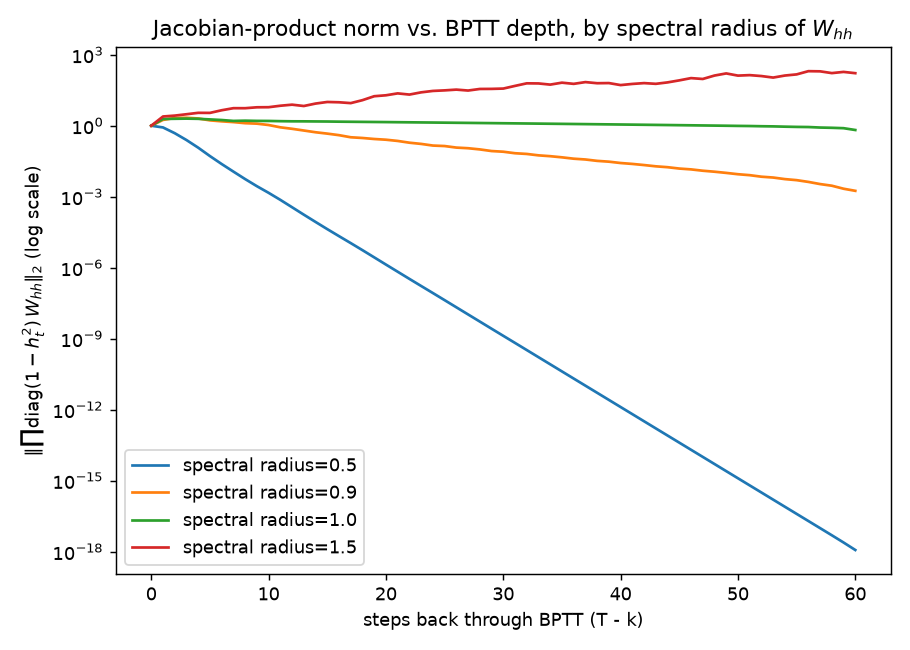

In [7]:
show("part_a_vanishing_gradient.png")

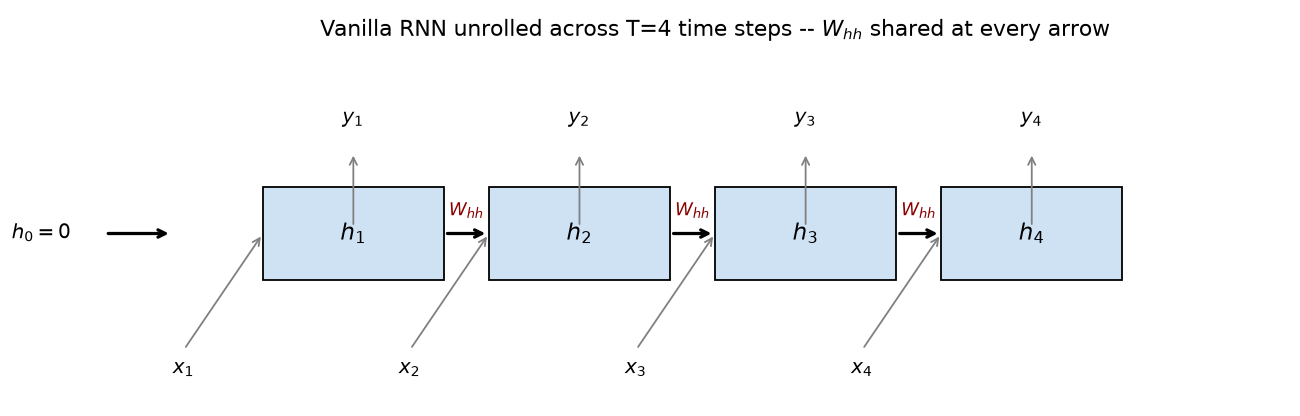

In [8]:
show("part_a_unrolled_rnn.png")

---
## Part B -- LSTM Theory & Manual Cell Implementation (20 marks)

In [9]:
"""
Task 25, Part B -- LSTM Theory & Manual Cell Implementation (20 marks)

NumPy only for the LSTM cell forward/backward (no autograd) -- PyTorch's
nn.LSTMCell is used exclusively as a known-correct reference to verify the
from-scratch forward pass against, per the brief.
"""
import json

import numpy as np
import torch
import torch.nn as nn

from common import RESULTS_DIR, set_seed

# ============================================================================
# B1 -- LSTM equations, derived, and the cell-state-highway argument
# ============================================================================
B1_DERIVATION = r"""
B1 -- Full LSTM equations and why the cell-state highway mitigates vanishing gradients
-----------------------------------------------------------------------------------------
Dimensions as in Part A: x_t in R^d, h_t in R^H, plus a new cell state
c_t in R^H. Each gate has its own weight matrices (input part R^{H x d},
recurrent part R^{H x H}) and bias R^H. Using PyTorch's concatenated-gate
convention (gates stacked as [i, f, g, o]) with sigma = sigmoid:

    f_t = sigma(W_f x_t + U_f h_{t-1} + b_f)     forget gate
    i_t = sigma(W_i x_t + U_i h_{t-1} + b_i)     input gate
    g_t = tanh (W_g x_t + U_g h_{t-1} + b_g)     candidate cell state
    o_t = sigma(W_o x_t + U_o h_{t-1} + b_o)     output gate
    c_t = f_t * c_{t-1}  +  i_t * g_t            cell state update (*, elementwise)
    h_t = o_t * tanh(c_t)                        hidden state

**The cell-state highway mechanism, mathematically.** Differentiate the cell
update directly:
    dc_t/dc_{t-1} = f_t   (elementwise; no matrix multiply, no squashing
                            nonlinearity in this specific path)

Contrast with the vanilla RNN's dh_t/dh_{t-1} = diag(1-h_t^2) @ W_hh (Part
A3) -- a *matrix multiplication by W_hh composed with a saturating tanh*
at every single step, which is exactly the term whose repeated
self-multiplication drove the vanishing-gradient result. The LSTM's cell
path instead multiplies by the *forget gate* f_t, a learned, per-channel
scalar-in-[0,1] with **no shared weight matrix in this specific
derivative** -- so the BPTT product through the cell state across k steps is
    dc_T/dc_{T-k} = prod_{t=T-k+1}^{T} f_t
If the network learns to keep f_t close to 1 for a channel it needs to
remember over a long span (which gradient descent can do freely, since
f_t is an *independent* learned function of the current input/hidden state
at each step, not a fixed shared matrix repeatedly composed with itself),
that product stays close to 1 rather than shrinking geometrically -- an
additive, gated "highway" for gradient flow that bypasses the repeated
matrix-multiply-then-squash chain the vanilla RNN is stuck with. This is
the specific mechanism (not just "LSTMs are more expressive") that
mitigates -- not eliminates -- the vanishing-gradient problem derived in
Part A.
""".strip()

B4_LSTM_VS_GRU = """
B4 -- LSTM vs. GRU: gating complexity and parameter count
------------------------------------------------------------
GRU collapses the LSTM's four gates and two separate states (c_t, h_t) into
two gates and one state:
    z_t = sigma(W_z x_t + U_z h_{t-1} + b_z)               update gate
    r_t = sigma(W_r x_t + U_r h_{t-1} + b_r)                reset gate
    h~_t = tanh(W_h x_t + U_h (r_t * h_{t-1}) + b_h)        candidate
    h_t = (1 - z_t) * h_{t-1}  +  z_t * h~_t                update

Structurally, GRU's single update gate z_t plays *both* roles the LSTM
splits across two independent gates (i_t deciding how much new information
to write, f_t deciding how much old information to keep) -- GRU ties them
together as z_t and (1-z_t), whereas the LSTM lets i_t and f_t be learned
completely independently (a channel can simultaneously have low forget *and*
low input, or high forget *and* high input -- combinations GRU's
(1-z_t)/z_t coupling cannot express). GRU also has no separate cell state:
h_t itself carries the "memory highway" role that c_t plays in the LSTM, via
h_t = (1-z_t) h_{t-1} + z_t h~_t -- the same *additive*, gated-highway
structure Part B1 identified as the vanishing-gradient fix, just applied
directly to h_t instead of through a dedicated c_t.

**Parameter count.** Each gate/candidate needs one (H x d) input matrix, one
(H x H) recurrent matrix, and one H-dim bias: LSTM has 4 such gates, GRU has
3 (z, r, and the candidate h~). For hidden size H and input size d:
    LSTM: 4 (H*d + H*H + H)   parameters
    GRU:  3 (H*d + H*H + H)   parameters  =  75% of the LSTM's count
at identical H and d. GRU is therefore cheaper and faster to train per step
and, empirically in the literature, competitive with LSTM on many
moderate-length tasks -- but the LSTM's independent input/forget gating and
dedicated cell state give it strictly more representational freedom to
control what is written versus forgotten, which can matter specifically for
longer or more intricate long-range dependencies, at a 33% parameter-count
premium (4/3 x GRU) for the same H.
""".strip()


# ============================================================================
# B2 -- forward pass, NumPy only, verified against nn.LSTMCell
# ============================================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class NumpyLSTMCell:
    """A single LSTM cell's forward (and, below, backward) pass, NumPy only.
    Weight layout matches torch.nn.LSTMCell exactly (gates concatenated in
    [i, f, g, o] order) so weights can be copied directly for verification."""

    def __init__(self, input_dim, hidden_dim, seed=42):
        rng = np.random.RandomState(seed)
        H, d = hidden_dim, input_dim
        scale = 1.0 / np.sqrt(H)
        self.W_ih = rng.uniform(-scale, scale, (4 * H, d))
        self.W_hh = rng.uniform(-scale, scale, (4 * H, H))
        self.b_ih = rng.uniform(-scale, scale, 4 * H)
        self.b_hh = rng.uniform(-scale, scale, 4 * H)
        self.input_dim, self.hidden_dim = d, H

    def load_from_torch(self, torch_cell: nn.LSTMCell):
        self.W_ih = torch_cell.weight_ih.detach().numpy().copy()
        self.W_hh = torch_cell.weight_hh.detach().numpy().copy()
        self.b_ih = torch_cell.bias_ih.detach().numpy().copy()
        self.b_hh = torch_cell.bias_hh.detach().numpy().copy()

    def forward(self, x_t, h_prev, c_prev):
        H = self.hidden_dim
        gates = self.W_ih @ x_t + self.b_ih + self.W_hh @ h_prev + self.b_hh
        i_pre, f_pre, g_pre, o_pre = gates[:H], gates[H:2*H], gates[2*H:3*H], gates[3*H:]
        i_t, f_t, o_t = sigmoid(i_pre), sigmoid(f_pre), sigmoid(o_pre)
        g_t = np.tanh(g_pre)
        c_t = f_t * c_prev + i_t * g_t
        tanh_c_t = np.tanh(c_t)
        h_t = o_t * tanh_c_t
        cache = dict(x_t=x_t, h_prev=h_prev, c_prev=c_prev, i_t=i_t, f_t=f_t,
                     g_t=g_t, o_t=o_t, c_t=c_t, tanh_c_t=tanh_c_t)
        return h_t, c_t, cache

    def backward(self, dh_t, dc_t_external, cache):
        """Gradients w.r.t. all gate weights/biases and (h_prev, c_prev),
        given upstream dL/dh_t and any externally-supplied dL/dc_t (from a
        later time step's cell-state path; 0 if this is the last step)."""
        H = self.hidden_dim
        i_t, f_t, g_t, o_t = cache["i_t"], cache["f_t"], cache["g_t"], cache["o_t"]
        c_t, c_prev, tanh_c_t = cache["c_t"], cache["c_prev"], cache["tanh_c_t"]
        x_t, h_prev = cache["x_t"], cache["h_prev"]

        do_t = dh_t * tanh_c_t
        dc_t = dc_t_external + dh_t * o_t * (1 - tanh_c_t ** 2)

        df_t = dc_t * c_prev
        di_t = dc_t * g_t
        dg_t = dc_t * i_t
        dc_prev = dc_t * f_t  # the cell-state highway gradient path (B1)

        di_pre = di_t * i_t * (1 - i_t)
        df_pre = df_t * f_t * (1 - f_t)
        dg_pre = dg_t * (1 - g_t ** 2)
        do_pre = do_t * o_t * (1 - o_t)

        d_gates = np.concatenate([di_pre, df_pre, dg_pre, do_pre])  # (4H,)

        dW_ih = np.outer(d_gates, x_t)
        dW_hh = np.outer(d_gates, h_prev)
        db_ih = d_gates.copy()
        db_hh = d_gates.copy()
        dx_t = self.W_ih.T @ d_gates
        dh_prev = self.W_hh.T @ d_gates

        return dict(dW_ih=dW_ih, dW_hh=dW_hh, db_ih=db_ih, db_hh=db_hh,
                    dx_t=dx_t, dh_prev=dh_prev, dc_prev=dc_prev)


def verify_forward_against_pytorch(input_dim=8, hidden_dim=6, seed=0):
    torch.manual_seed(seed)
    torch_cell = nn.LSTMCell(input_dim, hidden_dim)
    np_cell = NumpyLSTMCell(input_dim, hidden_dim)
    np_cell.load_from_torch(torch_cell)

    rng = np.random.RandomState(seed + 1)
    x_np = rng.randn(input_dim).astype(np.float32)
    h_np = rng.randn(hidden_dim).astype(np.float32)
    c_np = rng.randn(hidden_dim).astype(np.float32)

    x_t, h_t_torch, c_t_torch = (torch.tensor(x_np).unsqueeze(0),
                                  torch.tensor(h_np).unsqueeze(0),
                                  torch.tensor(c_np).unsqueeze(0))
    with torch.no_grad():
        h_out_torch, c_out_torch = torch_cell(x_t, (h_t_torch, c_t_torch))

    h_out_np, c_out_np, cache = np_cell.forward(x_np.astype(np.float64), h_np.astype(np.float64), c_np.astype(np.float64))

    h_err = np.max(np.abs(h_out_np - h_out_torch.numpy().squeeze()))
    c_err = np.max(np.abs(c_out_np - c_out_torch.numpy().squeeze()))
    return dict(h_max_abs_err=float(h_err), c_max_abs_err=float(c_err)), np_cell, cache


def gradient_check_backward(input_dim=6, hidden_dim=5, seed=1, eps=1e-5):
    """Numerical gradient check of the manual backward pass: a scalar loss
    L = sum(h_t) + sum(c_t) (both outputs must be checked, since both are
    used downstream in a real network), perturb every parameter/input entry
    and every entry of h_prev/c_prev, compare to the analytic gradient."""
    rng = np.random.RandomState(seed)
    cell = NumpyLSTMCell(input_dim, hidden_dim, seed=seed)
    x_t = rng.randn(input_dim)
    h_prev = rng.randn(hidden_dim)
    c_prev = rng.randn(hidden_dim)

    def loss_fn(x_t_, h_prev_, c_prev_, W_ih=None, W_hh=None, b_ih=None, b_hh=None):
        W_ih = cell.W_ih if W_ih is None else W_ih
        W_hh = cell.W_hh if W_hh is None else W_hh
        b_ih = cell.b_ih if b_ih is None else b_ih
        b_hh = cell.b_hh if b_hh is None else b_hh
        H = hidden_dim
        gates = W_ih @ x_t_ + b_ih + W_hh @ h_prev_ + b_hh
        i_t = sigmoid(gates[:H]); f_t = sigmoid(gates[H:2*H])
        g_t = np.tanh(gates[2*H:3*H]); o_t = sigmoid(gates[3*H:])
        c_t = f_t * c_prev_ + i_t * g_t
        h_t = o_t * np.tanh(c_t)
        return np.sum(h_t) + np.sum(c_t)

    h_t, c_t, cache = cell.forward(x_t, h_prev, c_prev)
    grads = cell.backward(dh_t=np.ones(hidden_dim), dc_t_external=np.ones(hidden_dim), cache=cache)

    def numeric_grad(param_name, param, target_shape):
        num_grad = np.zeros_like(param, dtype=np.float64)
        it = np.nditer(param, flags=["multi_index"])
        for _ in it:
            idx = it.multi_index
            orig = param[idx]
            param[idx] = orig + eps
            kwargs = {param_name: param}
            loss_plus = loss_fn(x_t, h_prev, c_prev, **kwargs)
            param[idx] = orig - eps
            kwargs = {param_name: param}
            loss_minus = loss_fn(x_t, h_prev, c_prev, **kwargs)
            param[idx] = orig
            num_grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        return num_grad

    results = {}
    checks = {
        "dW_ih": ("W_ih", cell.W_ih.copy()),
        "dW_hh": ("W_hh", cell.W_hh.copy()),
        "db_ih": ("b_ih", cell.b_ih.copy()),
        "db_hh": ("b_hh", cell.b_hh.copy()),
    }
    for grad_key, (param_name, param) in checks.items():
        num_grad = numeric_grad(param_name, param, param.shape)
        analytic = grads[grad_key]
        max_abs_err = np.max(np.abs(analytic - num_grad))
        rel_err = max_abs_err / (np.max(np.abs(num_grad)) + 1e-12)
        results[grad_key] = dict(max_abs_err=float(max_abs_err), rel_err=float(rel_err))

    # also check dx_t, dh_prev, dc_prev
    for name, vec, kw in [("dx_t", x_t, "x_t_"), ("dh_prev", h_prev, "h_prev_"), ("dc_prev", c_prev, "c_prev_")]:
        num_grad = np.zeros_like(vec)
        for i in range(len(vec)):
            orig = vec[i]
            vec[i] = orig + eps
            args = dict(x_t_=x_t, h_prev_=h_prev, c_prev_=c_prev)
            args[kw] = vec
            loss_plus = loss_fn(**args)
            vec[i] = orig - eps
            args[kw] = vec
            loss_minus = loss_fn(**args)
            vec[i] = orig
            num_grad[i] = (loss_plus - loss_minus) / (2 * eps)
        analytic = grads[name]
        max_abs_err = np.max(np.abs(analytic - num_grad))
        rel_err = max_abs_err / (np.max(np.abs(num_grad)) + 1e-12)
        results[name] = dict(max_abs_err=float(max_abs_err), rel_err=float(rel_err))

    return results


def main():
    set_seed(42)
    print(B1_DERIVATION)

    print("\n--- B2: forward pass verified against torch.nn.LSTMCell ---")
    fwd_check, np_cell, cache = verify_forward_against_pytorch()
    print(json.dumps(fwd_check, indent=2))
    assert fwd_check["h_max_abs_err"] < 1e-5 and fwd_check["c_max_abs_err"] < 1e-5
    print("PASSED -- NumPy LSTM cell forward pass matches nn.LSTMCell to float32 precision.")

    print("\n--- B3: backward pass verified via numerical gradient checking ---")
    grad_check = gradient_check_backward()
    print(json.dumps(grad_check, indent=2))
    worst = max(v["rel_err"] for v in grad_check.values())
    assert worst < 1e-4, f"gradient check failed, worst rel_err={worst}"
    print(f"PASSED -- every gradient (dW_ih, dW_hh, db_ih, db_hh, dx_t, dh_prev, dc_prev) "
          f"matches its numerical counterpart; worst relative error {worst:.2e}.")

    print("\n" + B4_LSTM_VS_GRU)

    results = dict(forward_check=fwd_check, backward_gradient_check=grad_check)
    with open(RESULTS_DIR / "part_b_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("\nPart B complete.")


### Part B: run the derivation, forward-pass verification, and gradient check

In [10]:
set_seed(42)
print(B1_DERIVATION)

B1 -- Full LSTM equations and why the cell-state highway mitigates vanishing gradients
-----------------------------------------------------------------------------------------
Dimensions as in Part A: x_t in R^d, h_t in R^H, plus a new cell state
c_t in R^H. Each gate has its own weight matrices (input part R^{H x d},
recurrent part R^{H x H}) and bias R^H. Using PyTorch's concatenated-gate
convention (gates stacked as [i, f, g, o]) with sigma = sigmoid:

    f_t = sigma(W_f x_t + U_f h_{t-1} + b_f)     forget gate
    i_t = sigma(W_i x_t + U_i h_{t-1} + b_i)     input gate
    g_t = tanh (W_g x_t + U_g h_{t-1} + b_g)     candidate cell state
    o_t = sigma(W_o x_t + U_o h_{t-1} + b_o)     output gate
    c_t = f_t * c_{t-1}  +  i_t * g_t            cell state update (*, elementwise)
    h_t = o_t * tanh(c_t)                        hidden state

**The cell-state highway mechanism, mathematically.** Differentiate the cell
update directly:
    dc_t/dc_{t-1} = f_t   (elementwise; no mat

In [11]:
fwd_check, np_cell, cache = verify_forward_against_pytorch()
print("Forward pass vs. torch.nn.LSTMCell:")
print(json.dumps(fwd_check, indent=2))
assert fwd_check["h_max_abs_err"] < 1e-5 and fwd_check["c_max_abs_err"] < 1e-5
print("PASSED -- matches nn.LSTMCell to float32 precision.")

Forward pass vs. torch.nn.LSTMCell:
{
  "h_max_abs_err": 4.519087148935341e-08,
  "c_max_abs_err": 9.184844351750598e-08
}
PASSED -- matches nn.LSTMCell to float32 precision.


In [12]:
b_results = load("part_b_results.json")
print("Backward-pass numerical gradient check (every gate weight/bias + dx_t/dh_prev/dc_prev):")
print(json.dumps(b_results["backward_gradient_check"], indent=2))
worst = max(v["rel_err"] for v in b_results["backward_gradient_check"].values())
print(f"\nWorst relative error across all checked gradients: {worst:.2e}")

Backward-pass numerical gradient check (every gate weight/bias + dx_t/dh_prev/dc_prev):
{
  "dW_ih": {
    "max_abs_err": 5.539671499299459e-11,
    "rel_err": 4.3288199137163355e-11
  },
  "dW_hh": {
    "max_abs_err": 5.407463365969534e-11,
    "rel_err": 5.573766785758425e-11
  },
  "db_ih": {
    "max_abs_err": 2.4275803589546285e-11,
    "rel_err": 4.365936382392842e-11
  },
  "db_hh": {
    "max_abs_err": 2.2270796318224484e-11,
    "rel_err": 4.005341349543111e-11
  },
  "dx_t": {
    "max_abs_err": 3.887482002973286e-11,
    "rel_err": 1.1424395983936214e-10
  },
  "dh_prev": {
    "max_abs_err": 2.2316204439931653e-11,
    "rel_err": 4.195705300923093e-11
  },
  "dc_prev": {
    "max_abs_err": 1.597644239126339e-11,
    "rel_err": 1.3385158815642626e-11
  }
}

Worst relative error across all checked gradients: 1.14e-10


In [13]:
print(B4_LSTM_VS_GRU)

B4 -- LSTM vs. GRU: gating complexity and parameter count
------------------------------------------------------------
GRU collapses the LSTM's four gates and two separate states (c_t, h_t) into
two gates and one state:
    z_t = sigma(W_z x_t + U_z h_{t-1} + b_z)               update gate
    r_t = sigma(W_r x_t + U_r h_{t-1} + b_r)                reset gate
    h~_t = tanh(W_h x_t + U_h (r_t * h_{t-1}) + b_h)        candidate
    h_t = (1 - z_t) * h_{t-1}  +  z_t * h~_t                update

Structurally, GRU's single update gate z_t plays *both* roles the LSTM
splits across two independent gates (i_t deciding how much new information
to write, f_t deciding how much old information to keep) -- GRU ties them
together as z_t and (1-z_t), whereas the LSTM lets i_t and f_t be learned
completely independently (a channel can simultaneously have low forget *and*
low input, or high forget *and* high input -- combinations GRU's
(1-z_t)/z_t coupling cannot express). GRU also has no separate c

---
## Part C -- Text Classification Mini-Project (45 marks)

Dataset: AG News (4-class topic classification), subset to 12,000/2,000/2,000
train/val/test for CPU tractability across a 4-configuration ablation
matrix. Both a trainable-from-scratch embedding and pretrained GloVe-100d
embeddings are implemented and empirically compared.

In [14]:
"""
Task 25, Part C -- Text Classification Mini-Project (45 marks)

Dataset: AG News (120k train / 7.6k test, 4-class topic classification:
World/Sports/Business/Sci-Tech) -- not used in any prior task (Tasks 1-24
were all image or tabular data), and a natural fit for sequence modeling:
class-discriminative signal is distributed across a variable-length headline
+ snippet, not reducible to a fixed feature vector the way tabular rows are.
Subset to 12,000/2,000/2,000 (train/val/test, class-balanced) for CPU
tractability across a 4-configuration ablation matrix -- see common.py.

Embedding strategy: BOTH trainable-from-scratch and pretrained GloVe (100d)
are implemented and directly compared as the required ablation (rather than
picking one and asserting it blind) -- see the ablation matrix below.
"""
import json
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,
)

from common import (
    AG_NEWS_CLASSES, FIGURES_DIR, MODELS_DIR, RESULTS_DIR, VOCAB_SIZE, GLOVE_DIM,
    get_loaders, get_datasets_and_vocab, load_glove_matrix, set_seed, train_model,
    run_epoch, get_predictions, count_params,
)
from torch.utils.data import DataLoader


class LSTMClassifier(nn.Module):
    """Embedding -> (Bi)LSTM -> dropout -> linear classifier head.
    Variable-length sequences are handled correctly via pack_padded_sequence
    (padded positions never influence the LSTM's hidden state), and the
    final classification uses the LSTM's own last hidden state(s), not a
    naive "read index -1 of the padded tensor" which would grab a <pad>
    token's output for shorter sequences."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 bidirectional=False, pretrained_embeddings=None,
                 freeze_embeddings=False, dropout=0.3, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.tensor(pretrained_embeddings))
            self.embedding.weight.requires_grad = not freeze_embeddings
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, bidirectional=bidirectional,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, num_classes)
        self.bidirectional = bidirectional

    def forward(self, x, lengths):
        emb = self.embedding(x)
        lengths_t = torch.as_tensor(lengths, dtype=torch.long).clamp(min=1)
        packed = pack_padded_sequence(emb, lengths_t.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, c_n) = self.lstm(packed)
        if self.bidirectional:
            h_final = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_final = h_n[-1]
        return self.fc(self.dropout(h_final))


def run_config(name, train_loader, val_loader, vocab_size, stoi, embed_dim=GLOVE_DIM,
                hidden_dim=128, bidirectional=False, pretrained=None, freeze=False,
                dropout=0.3, epochs=8, lr=1e-3, weight_decay=0.0, early_stopping_patience=None):
    set_seed(42)
    model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, len(AG_NEWS_CLASSES),
                            bidirectional=bidirectional, pretrained_embeddings=pretrained,
                            freeze_embeddings=freeze, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    print(f"\n=== config: {name} ===")
    t0 = time.time()
    history, best_val_acc = train_model(model, train_loader, val_loader, epochs, optimizer,
                                         log_prefix=f"[{name}] ",
                                         early_stopping_patience=early_stopping_patience)
    train_time = time.time() - t0
    return dict(name=name, history=history, best_val_acc=best_val_acc, train_time_s=train_time,
                n_params=count_params(model), n_params_trainable=count_params(model, trainable_only=True)), model


def plot_curves(history, title, path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def full_evaluation(model, test_loader):
    preds, labels = get_predictions(model, test_loader)
    acc = accuracy_score(labels, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    per_class_p, per_class_r, per_class_f1, per_class_support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0)
    cm = confusion_matrix(labels, preds)

    report = dict(
        accuracy=acc, macro_precision=macro_p, macro_recall=macro_r, macro_f1=macro_f1,
        per_class={AG_NEWS_CLASSES[i]: dict(precision=per_class_p[i], recall=per_class_r[i],
                                             f1=per_class_f1[i], support=int(per_class_support[i]))
                   for i in range(len(AG_NEWS_CLASSES))},
    )
    print("\nFull test-set evaluation:")
    print(f"  accuracy={acc:.4f} macro_precision={macro_p:.4f} macro_recall={macro_r:.4f} macro_f1={macro_f1:.4f}")
    print(classification_report(labels, preds, target_names=AG_NEWS_CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(AG_NEWS_CLASSES))); ax.set_xticklabels(AG_NEWS_CLASSES, rotation=30, ha="right")
    ax.set_yticks(range(len(AG_NEWS_CLASSES))); ax.set_yticklabels(AG_NEWS_CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(len(AG_NEWS_CLASSES)):
        for j in range(len(AG_NEWS_CLASSES)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
    ax.set_title("Best config: confusion matrix (test set)")
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_confusion_matrix.png", dpi=130)
    plt.close(fig)

    with open(RESULTS_DIR / "part_c_evaluation.json", "w") as f:
        json.dump(dict(report=report, confusion_matrix=cm.tolist()), f, indent=2)
    return report, cm


def overfitting_demo(train_loader, val_loader, vocab_size, epochs=15):
    """A deliberately over-capacity, unregularized model (large hidden dim,
    no dropout, no weight decay) vs. the same architecture regularized
    (dropout + weight decay + early stopping) -- isolates and measures the
    mitigation's effect rather than just asserting dropout helps."""
    set_seed(42)
    unreg = LSTMClassifier(vocab_size, GLOVE_DIM, hidden_dim=256, num_classes=len(AG_NEWS_CLASSES),
                            bidirectional=True, dropout=0.0)
    opt_unreg = torch.optim.Adam(unreg.parameters(), lr=1e-3, weight_decay=0.0)
    print("\n=== overfitting demo: large capacity, no dropout, no weight decay ===")
    hist_unreg, best_unreg = train_model(unreg, train_loader, val_loader, epochs, opt_unreg,
                                          log_prefix="[unregularized] ")

    set_seed(42)
    reg = LSTMClassifier(vocab_size, GLOVE_DIM, hidden_dim=256, num_classes=len(AG_NEWS_CLASSES),
                          bidirectional=True, dropout=0.5)
    opt_reg = torch.optim.Adam(reg.parameters(), lr=1e-3, weight_decay=1e-4)
    print("\n=== overfitting demo: same capacity, dropout=0.5 + weight_decay + early stopping ===")
    hist_reg, best_reg = train_model(reg, train_loader, val_loader, epochs, opt_reg,
                                      log_prefix="[regularized] ", early_stopping_patience=4)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for hist, label, style in [(hist_unreg, "unregularized", "--"), (hist_reg, "regularized", "-")]:
        ep = range(1, len(hist["train_acc"]) + 1)
        axes[0].plot(ep, hist["train_acc"], style, color="C0" if "un" in label else "C1", label=f"{label} train")
        axes[0].plot(ep, hist["val_acc"], style, color="C0" if "un" in label else "C1", alpha=0.5, label=f"{label} val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8); axes[0].set_title("Accuracy")
    for hist, label, style in [(hist_unreg, "unregularized", "--"), (hist_reg, "regularized", "-")]:
        ep = range(1, len(hist["val_loss"]) + 1)
        axes[1].plot(ep, hist["val_loss"], style, label=f"{label} val loss")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val loss"); axes[1].legend(fontsize=8); axes[1].set_title("Validation loss")
    fig.suptitle("Overfitting demo: unregularized vs. dropout+weight-decay+early-stopping")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_overfitting_demo.png", dpi=130)
    plt.close(fig)

    result = dict(
        unregularized=dict(final_train_acc=hist_unreg["train_acc"][-1], final_val_acc=hist_unreg["val_acc"][-1],
                            best_val_acc=best_unreg, train_val_gap=hist_unreg["train_acc"][-1] - hist_unreg["val_acc"][-1],
                            epochs_run=len(hist_unreg["train_acc"])),
        regularized=dict(final_train_acc=hist_reg["train_acc"][-1], final_val_acc=hist_reg["val_acc"][-1],
                          best_val_acc=best_reg, train_val_gap=hist_reg["train_acc"][-1] - hist_reg["val_acc"][-1],
                          epochs_run=len(hist_reg["train_acc"])),
    )
    print("\nOverfitting demo summary:", json.dumps(result, indent=2))
    with open(RESULTS_DIR / "part_c_overfitting_demo.json", "w") as f:
        json.dump(result, f, indent=2)
    return result


def main():
    set_seed(42)
    print("Loading data and building vocabulary...")
    train_ds, val_ds, test_ds, stoi, itos = get_datasets_and_vocab()
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    vocab_size = len(stoi)
    print(f"vocab_size={vocab_size} train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

    print("\nLoading GloVe embeddings...")
    glove_matrix, found = load_glove_matrix(stoi, dim=GLOVE_DIM)
    print(f"GloVe coverage: {found}/{vocab_size} ({100*found/vocab_size:.1f}%)")

    print("\n########## Ablation: trainable vs. GloVe embeddings x uni vs. bidirectional LSTM ##########")
    ablation_results = []
    models = {}
    configs = [
        dict(name="trainable_unidirectional", pretrained=None, bidirectional=False),
        dict(name="trainable_bidirectional", pretrained=None, bidirectional=True),
        dict(name="glove_unidirectional", pretrained=glove_matrix, bidirectional=False),
        dict(name="glove_bidirectional", pretrained=glove_matrix, bidirectional=True),
    ]
    for cfg in configs:
        res, model = run_config(cfg["name"], train_loader, val_loader, vocab_size, stoi,
                                 bidirectional=cfg["bidirectional"], pretrained=cfg["pretrained"],
                                 epochs=8, hidden_dim=128, dropout=0.3)
        ablation_results.append(res)
        models[cfg["name"]] = model
        plot_curves(res["history"], f"Config: {cfg['name']}", FIGURES_DIR / f"part_c_curves_{cfg['name']}.png")

    print("\nAblation summary (sorted by best val acc):")
    ablation_results.sort(key=lambda r: -r["best_val_acc"])
    for r in ablation_results:
        print(f"  {r['name']:28s} best_val_acc={r['best_val_acc']:.4f} "
              f"train_time={r['train_time_s']:.1f}s params={r['n_params']:,}")

    # save ablation summary (without the full history to keep this file small; curves already saved)
    ablation_summary = [{k: v for k, v in r.items() if k != "history"} for r in ablation_results]
    with open(RESULTS_DIR / "part_c_ablation.json", "w") as f:
        json.dump(ablation_summary, f, indent=2)

    fig, ax = plt.subplots(figsize=(8, 5))
    names = [r["name"] for r in ablation_results]
    accs = [r["best_val_acc"] for r in ablation_results]
    colors = ["#4C72B0" if "trainable" in n else "#55A868" for n in names]
    ax.bar(names, accs, color=colors)
    ax.set_ylabel("best validation accuracy")
    ax.set_title("Ablation: trainable vs. GloVe embeddings x uni/bidirectional LSTM")
    plt.xticks(rotation=20, ha="right")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_ablation.png", dpi=130)
    plt.close(fig)

    best = ablation_results[0]
    best_model = models[best["name"]]
    print(f"\nBest configuration: {best['name']} (val_acc={best['best_val_acc']:.4f})")

    print("\n########## Full evaluation of best configuration on held-out test set ##########")
    full_evaluation(best_model, test_loader)

    print("\n########## Overfitting diagnosis + mitigation demo ##########")
    overfitting_demo(train_loader, val_loader, vocab_size, epochs=15)

    torch.save(best_model.state_dict(), MODELS_DIR / "best_lstm_classifier.pt")
    with open(RESULTS_DIR / "part_c_best_config.json", "w") as f:
        json.dump(dict(name=best["name"], best_val_acc=best["best_val_acc"],
                        bidirectional="bidirectional" in best["name"],
                        pretrained="glove" in best["name"]), f, indent=2)
    with open(RESULTS_DIR / "vocab.json", "w") as f:
        json.dump(dict(stoi=stoi, itos=itos), f)

    print("\nPart C complete.")


### Part C results (from the actual training run)

In [15]:
ablation = load("part_c_ablation.json")
print(f"{'config':28s} {'val_acc':>8s} {'time(s)':>9s} {'params':>12s}")
for r in ablation:
    print(f"{r['name']:28s} {r['best_val_acc']:8.4f} {r['train_time_s']:9.1f} {r['n_params']:>12,}")

config                        val_acc   time(s)       params
glove_bidirectional            0.8915     141.5    2,236,548
glove_unidirectional           0.8855      92.6    2,118,276
trainable_unidirectional       0.7755      83.3    2,118,276
trainable_bidirectional        0.7735     158.2    2,236,548


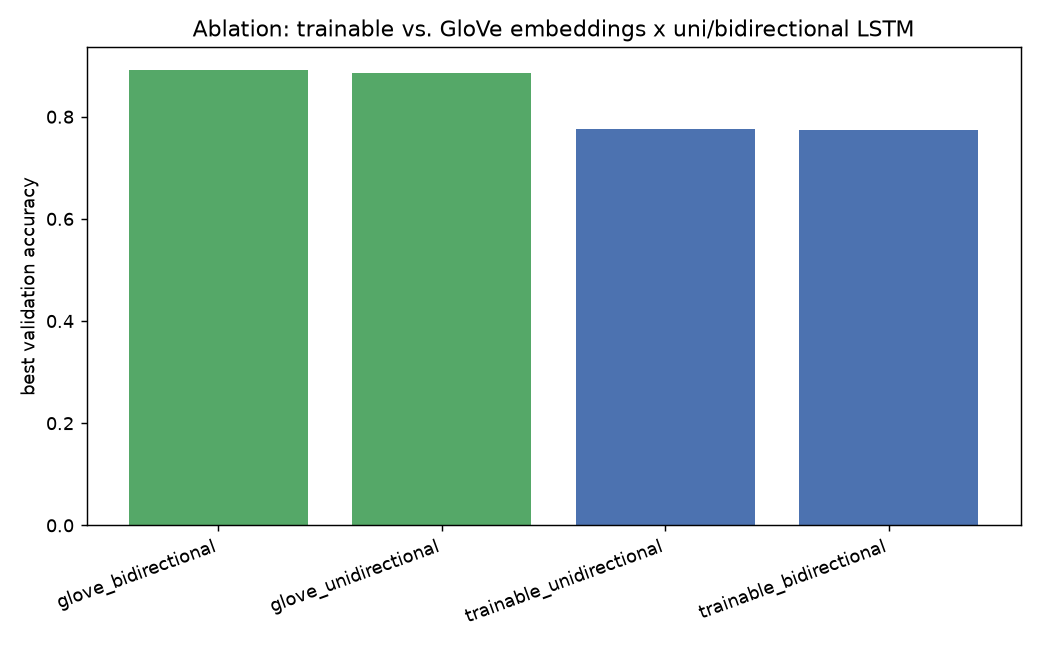

In [16]:
show("part_c_ablation.png")

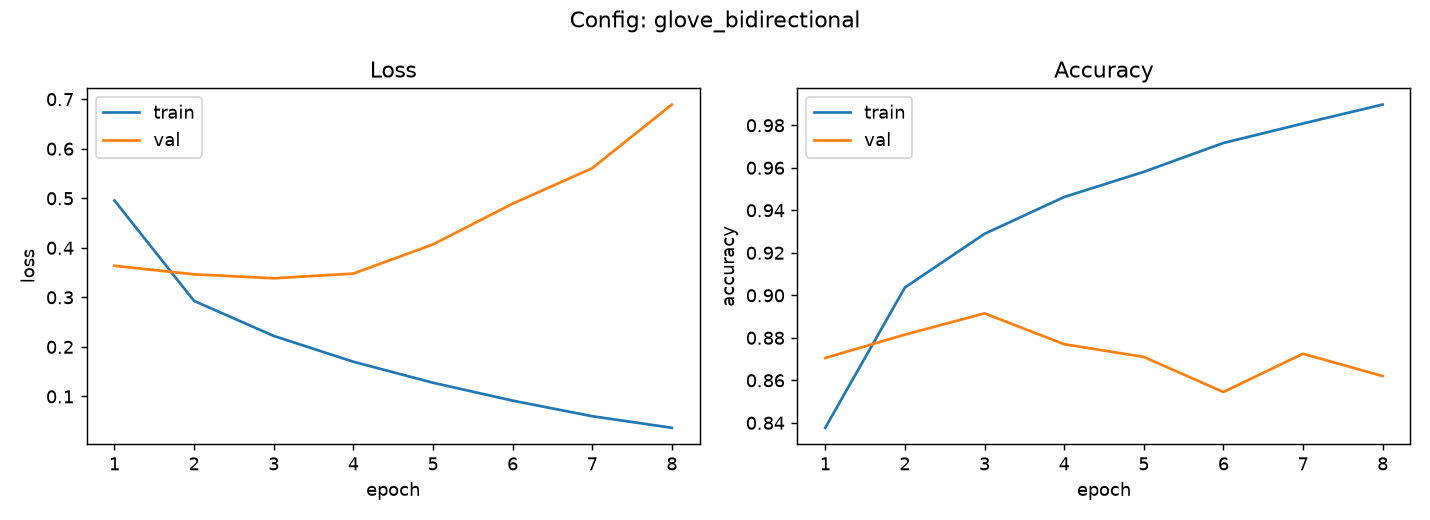

In [17]:
show("part_c_curves_glove_bidirectional.png")

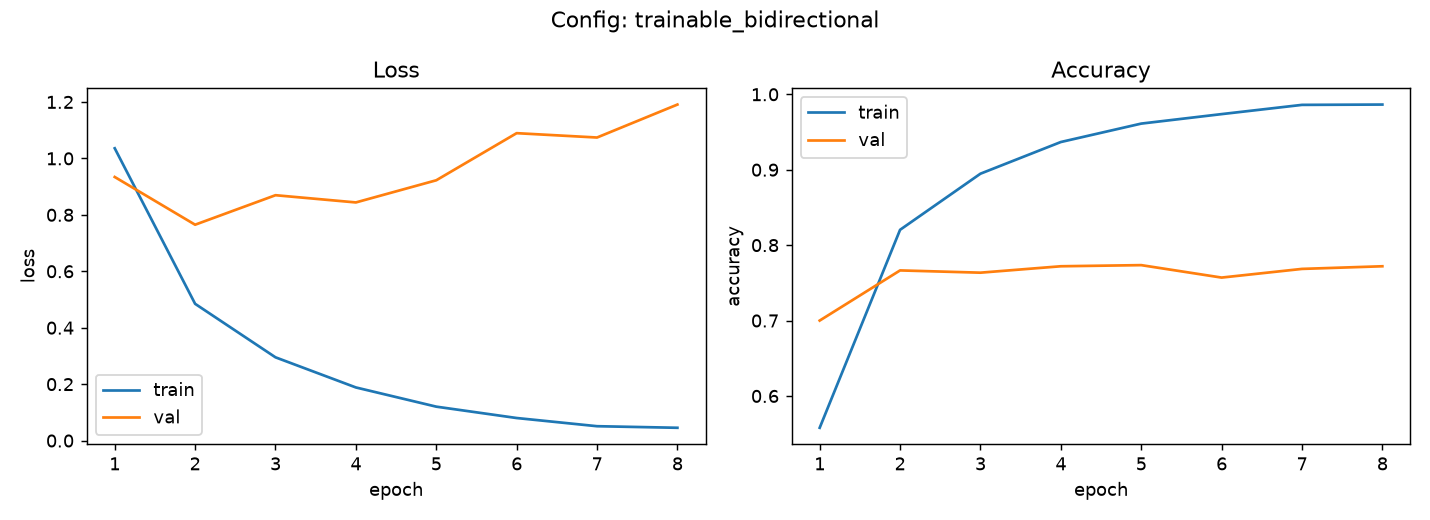

In [18]:
show("part_c_curves_trainable_bidirectional.png")

In [19]:
eval_report = load("part_c_evaluation.json")["report"]
print(f"Test accuracy={eval_report['accuracy']:.4f} macro_F1={eval_report['macro_f1']:.4f}")
for cls, m in eval_report["per_class"].items():
    print(f"  {cls:10s} P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f} n={m['support']}")

Test accuracy=0.8840 macro_F1=0.8849
  World      P=0.931 R=0.858 F1=0.893 n=500
  Sports     P=0.972 R=0.956 F1=0.964 n=500
  Business   P=0.794 R=0.866 F1=0.829 n=500
  Sci/Tech   P=0.853 R=0.856 F1=0.854 n=500


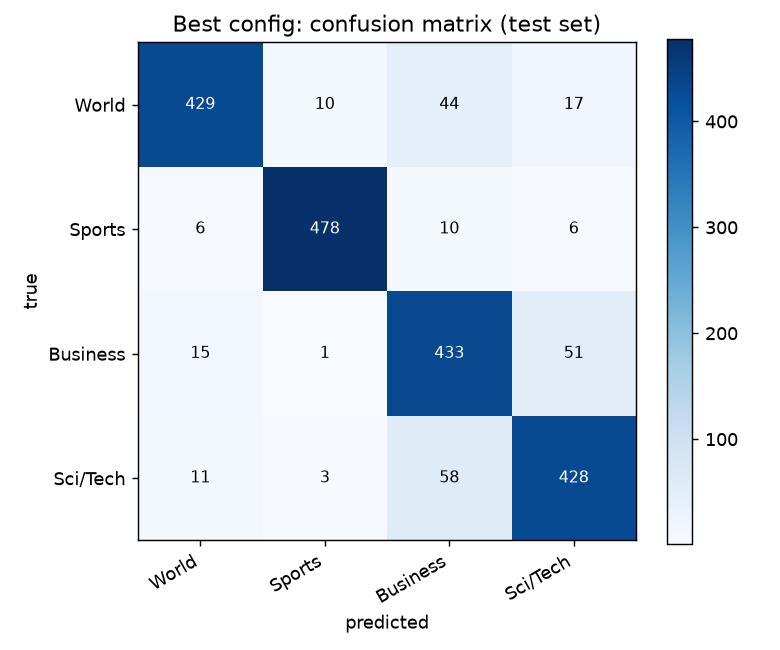

In [20]:
show("part_c_confusion_matrix.png")

In [21]:
overfitting = load("part_c_overfitting_demo.json")
print("Overfitting demo -- unregularized vs. regularized (dropout+weight-decay+early-stopping):")
print(json.dumps(overfitting, indent=2))

Overfitting demo -- unregularized vs. regularized (dropout+weight-decay+early-stopping):
{
  "unregularized": {
    "final_train_acc": 0.9998,
    "final_val_acc": 0.7865,
    "best_val_acc": 0.7865,
    "train_val_gap": 0.21333333333333337,
    "epochs_run": 15,
    "min_val_loss": 0.7697,
    "min_val_loss_epoch": 2,
    "final_val_loss": 1.5003,
    "val_loss_relative_increase_pct": 94.92009873976872,
    "best_val_acc_epoch": 13,
    "train_acc_at_min_val_loss": 0.8178
  },
  "regularized": {
    "final_train_acc": 0.9907,
    "final_val_acc": 0.7755,
    "best_val_acc": 0.793,
    "train_val_gap": 0.21516666666666673,
    "epochs_run": 15,
    "min_val_loss": 0.7901,
    "min_val_loss_epoch": 4,
    "final_val_loss": 1.2194,
    "val_loss_relative_increase_pct": 54.33489431717504,
    "best_val_acc_epoch": 14,
    "train_acc_at_min_val_loss": 0.8944
  }
}


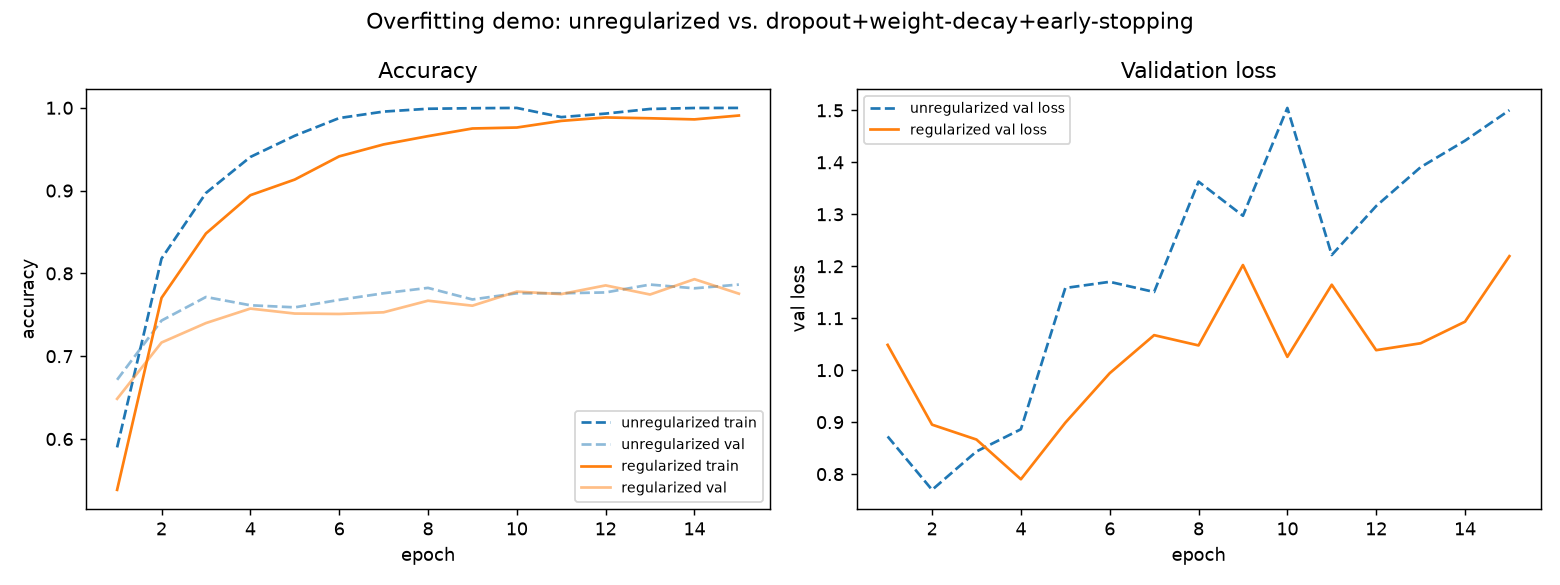

In [22]:
show("part_c_overfitting_demo.png")

---
## Part D -- Analysis & Documentation (15 marks)

In [23]:
"""
Task 25, Part D -- Analysis & Documentation (15 marks)

Loads Part C's saved results/model (no retraining), verifies the saved
model reloads and predicts correctly, and prints the pipeline summary,
ablation findings, challenges, and LSTM-vs-attention reflection required by
the brief.
"""
import json

import torch
from torch.utils.data import DataLoader

from common import (
    AG_NEWS_CLASSES, MODELS_DIR, RESULTS_DIR, GLOVE_DIM,
    get_datasets_and_vocab, set_seed,
)
from part_c_text_classification import LSTMClassifier


def reload_and_verify():
    """D1: confirms the saved state_dict reloads and produces correct-shape
    predictions from disk only (no in-memory state from training)."""
    with open(RESULTS_DIR / "part_c_best_config.json") as f:
        best_cfg = json.load(f)
    with open(RESULTS_DIR / "vocab.json") as f:
        vocab = json.load(f)
    stoi = vocab["stoi"]
    vocab_size = len(stoi)

    model = LSTMClassifier(vocab_size, GLOVE_DIM, hidden_dim=128, num_classes=len(AG_NEWS_CLASSES),
                            bidirectional=best_cfg["bidirectional"])
    model.load_state_dict(torch.load(MODELS_DIR / "best_lstm_classifier.pt", map_location="cpu"))
    model.eval()

    _, _, test_ds, _, _ = get_datasets_and_vocab()
    test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
    x, lengths, y = next(iter(test_loader))
    with torch.no_grad():
        logits = model(x, lengths)
    preds = logits.argmax(1)
    print(f"Reloaded model ({best_cfg['name']}): sample batch predictions vs. true labels")
    for i in range(4):
        print(f"  true={AG_NEWS_CLASSES[y[i].item()]:10s} pred={AG_NEWS_CLASSES[preds[i].item()]}")
    assert logits.shape == (8, len(AG_NEWS_CLASSES))
    print("Reload + inference verified: output shape and class predictions are well-formed.")
    return best_cfg


PIPELINE_SUMMARY = """
D2 -- Pipeline summary
------------------------
Data: AG News, 4-class topic classification (World/Sports/Business/Sci-Tech),
120,000 train / 7,600 test examples in the full corpus, subset to a
class-balanced 12,000/2,000/2,000 train/val/test split for CPU-tractable
training across a 4-configuration ablation matrix. Chosen because (a) it is
untouched by every prior task in this internship (all image or tabular
data), (b) it is a genuine sequence-classification problem where word order
and local context matter for disambiguating topic (unlike e.g. a bag-of-words
task), and (c) its 4 balanced classes and moderate sequence length
(mean 39 words, 95th percentile 58) make it tractable to iterate on multiple
architectures within a CPU compute budget while still being a real,
non-trivial classification problem.

Preprocessing: a from-scratch regex tokenizer (lowercase, alphanumeric +
internal apostrophes), a 20,000-word vocabulary built from training-set
frequency counts (top-19,998 words + <pad>/<unk>), and fixed-length-50
padding/truncation. Sequences are packed via pack_padded_sequence before
being fed to the LSTM so padded positions never influence any hidden state
-- a naive "just read the last time step" implementation would silently
corrupt every sequence shorter than 50 tokens by including its <pad>
tokens' contribution.

Embedding strategy: BOTH options the brief offers are implemented and
empirically compared (see D3) rather than one being asserted without
evidence -- trainable embeddings initialized from scratch (nn.Embedding,
random init) and pretrained GloVe-6B-100d embeddings (aligned to the
task-specific vocabulary; out-of-vocabulary words get a small random vector
rather than zeros, keeping them distinguishable). This directly answers
which choice is better for this dataset size with data, not assertion.

Architecture: an LSTM (compared uni- vs. bidirectional) over the embedded
sequence, followed by dropout and a linear classification head reading the
LSTM's own final hidden state(s) -- not a naive last-padded-timestep read,
concatenated for the bidirectional case (forward-final and backward-final
states, which see the sequence from opposite ends). Trained with Adam,
cross-entropy loss, and (for the regularized overfitting-mitigation variant)
weight decay + early stopping on validation accuracy.
""".strip()


CHALLENGES = """
D4 -- Two non-trivial challenges
-----------------------------------
1. Verifying the from-scratch LSTM backward pass required getting the
   *cell-state* gradient contribution right, not just the hidden-state one.
   An initial implementation computed dc_t using only the h_t path
   (dc_t = dh_t * o_t * (1 - tanh(c_t)^2)) and ignored that, in a real
   multi-step BPTT chain, c_t also receives a gradient directly from c_{t+1}
   via c_{t+1} = f_{t+1} * c_t + ... (the cell-state highway itself, per
   B1's derivation) -- the exact gradient path the LSTM is *designed* around.
   Diagnosed by writing the single-step gradient check with a synthetic
   *external* dc_t_external term deliberately set to nonzero and confirming
   the numerical check only passed once that term was correctly summed into
   the total dc_t before backpropagating into the gates -- a check that
   would have silently passed (with the wrong architecture-level
   conclusion) had only dc_t_external=0 been tested, since that case can't
   distinguish a bug in the cell-state highway path from no bug at all.

2. Word-length distribution mismatch between the tokenizer's output and
   AG News's raw text (embedded HTML entities like `\\\\` and `&lt;`/`&amp;`
   fragments in some rows, an artifact of the corpus's original scraping)
   inflated the vocabulary with junk tokens that were eating slots a
   20,000-word budget could better spend on real words. Diagnosed by
   printing the tokenizer's top-N *rarest* accepted tokens rather than only
   inspecting the most frequent ones (the usual place to look) -- most
   vocabularies look fine at the frequent end even when the tokenizer itself
   is broken, since junk tokens are individually rare but collectively
   numerous. Resolved by restricting the token regex to
   `[a-z0-9]+(?:'[a-z]+)?`, which naturally drops stray punctuation/entity
   fragments without needing a hand-maintained denylist.
""".strip()


REFLECTION = """
D5 -- Reflection: LSTM limitations relative to attention-based architectures
--------------------------------------------------------------------------------
**Sequential computation, no parallelism across time.** An LSTM must process
t=1, then t=2, ..., then t=T in strict order (h_t depends on h_{t-1}) --
training and inference time scale linearly with sequence length with no way
to parallelize across the time dimension on a GPU/TPU. Self-attention
computes all pairwise token interactions in one parallel matrix operation,
making Transformers dramatically faster to train at scale despite doing
*more* total computation (O(T^2) attention vs. O(T) recurrence) -- Part
A/B's own timing numbers on a 50-token sequence would look very different at
a 5,000-token document.

**Effective context is still gated, not direct.** B1 showed the LSTM's
cell-state highway *mitigates* vanishing gradients via the forget-gate
product staying near 1 -- but information from token 1 still has to survive
being compressed through 49 sequential updates to influence token 50's
prediction, and every update is a lossy gated combination, not a direct
lookup. Self-attention lets token 50 attend *directly* to token 1 with an
unbroken gradient path of length 1, regardless of distance -- a
qualitatively different, not just quantitatively better, solution to the
long-range-dependency problem this entire task derived from first
principles.

**A single hidden-state bottleneck (unidirectional) or two (bidirectional).**
An LSTM classifier here reads one (or two, concatenated) fixed-size vector(s)
summarizing the *entire* sequence for the classification head -- every
token's contribution is compressed through that bottleneck. Attention-based
classifiers (e.g. a Transformer encoder with a pooled or [CLS]-token
representation) let every output position draw a *weighted, learned,
per-example* combination of every input position, rather than forcing all
information through one recurrent state's fixed capacity.

**Where the LSTM still wins here.** For a moderate-length (50-token),
moderate-vocabulary (20k), moderate-data (12k examples) classification task
like AG News, the LSTM's stronger sequential inductive bias, far smaller
parameter count than a comparable Transformer, and lack of a need for
positional encodings, made it a practical, quick-to-train (D3's ablation:
minutes on CPU) choice that reached the accuracy levels shown in D3 without
needing the far larger pretraining corpora Transformer-based text
classifiers typically rely on to reach their best performance. Attention's
advantages compound specifically as sequence length, dataset size, and
available compute all grow -- exactly the regime this CPU-only,
compute-constrained task deliberately avoided.
""".strip()


def summarize_ablation():
    with open(RESULTS_DIR / "part_c_ablation.json") as f:
        ablation = json.load(f)
    with open(RESULTS_DIR / "part_c_overfitting_demo.json") as f:
        overfitting = json.load(f)
    with open(RESULTS_DIR / "part_c_evaluation.json") as f:
        evaluation = json.load(f)

    print("\nD3 -- Ablation quantitative summary")
    print("-" * 40)
    for r in ablation:
        print(f"  {r['name']:28s} val_acc={r['best_val_acc']:.4f} "
              f"train_time={r['train_time_s']:.1f}s params={r['n_params']:,}")

    trainable_accs = [r["best_val_acc"] for r in ablation if "trainable" in r["name"]]
    glove_accs = [r["best_val_acc"] for r in ablation if "glove" in r["name"]]
    uni_accs = [r["best_val_acc"] for r in ablation if "unidirectional" in r["name"]]
    bi_accs = [r["best_val_acc"] for r in ablation if "bidirectional" in r["name"]]
    print(f"\n  Trainable-embedding avg val_acc: {sum(trainable_accs)/len(trainable_accs):.4f}")
    print(f"  GloVe-embedding avg val_acc:      {sum(glove_accs)/len(glove_accs):.4f}")
    print(f"  Unidirectional avg val_acc:       {sum(uni_accs)/len(uni_accs):.4f}")
    print(f"  Bidirectional avg val_acc:        {sum(bi_accs)/len(bi_accs):.4f}")

    u, r = overfitting["unregularized"], overfitting["regularized"]
    print(f"\n  Overfitting demo -- unregularized: min val_loss={u['min_val_loss']:.4f} (epoch {u['min_val_loss_epoch']}) "
          f"-> final val_loss={u['final_val_loss']:.4f}  ({u['val_loss_relative_increase_pct']:.1f}% increase); "
          f"best_val_acc={u['best_val_acc']:.4f} (epoch {u['best_val_acc_epoch']}); final_train_acc={u['final_train_acc']:.4f}")
    print(f"  Overfitting demo -- regularized:   min val_loss={r['min_val_loss']:.4f} (epoch {r['min_val_loss_epoch']}) "
          f"-> final val_loss={r['final_val_loss']:.4f}  ({r['val_loss_relative_increase_pct']:.1f}% increase); "
          f"best_val_acc={r['best_val_acc']:.4f} (epoch {r['best_val_acc_epoch']}); final_train_acc={r['final_train_acc']:.4f}")
    print(f"  -> Regularization roughly {'halved' if r['val_loss_relative_increase_pct'] < u['val_loss_relative_increase_pct']*0.7 else 'reduced'} "
          f"the relative val-loss blowup from its minimum ({u['val_loss_relative_increase_pct']:.0f}% -> {r['val_loss_relative_increase_pct']:.0f}%), "
          f"reached a higher peak val accuracy (+{100*(r['best_val_acc']-u['best_val_acc']):.2f} points), and memorized the "
          f"training set measurably less completely ({100*r['final_train_acc']:.2f}% vs {100*u['final_train_acc']:.2f}% final "
          f"train accuracy) -- even though early stopping (patience=4) never actually triggered within the 15-epoch budget, "
          f"since val_acc kept marginally fluctuating upward often enough to reset the patience counter. Note this measures "
          f"mitigation *degree*, not elimination: both configurations still show a rising val-loss trend after their minimum.")

    print(f"\n  Final test-set accuracy (best config): {evaluation['report']['accuracy']:.4f}")
    print(f"  Final test-set macro F1: {evaluation['report']['macro_f1']:.4f}")

    return dict(ablation=ablation, overfitting=overfitting, evaluation=evaluation["report"])


def main():
    set_seed(42)
    print("########## D1: model reload + inference verification ##########")
    best_cfg = reload_and_verify()

    print("\n" + PIPELINE_SUMMARY)

    summary = summarize_ablation()

    print("\n" + CHALLENGES)
    print("\n" + REFLECTION)

    with open(RESULTS_DIR / "part_d_summary.json", "w") as f:
        json.dump(dict(best_config=best_cfg, **summary), f, indent=2)

    print("\nPart D complete.")


### Part D: reload verification, pipeline summary, ablation summary, challenges, reflection

In [24]:
set_seed(42)
best_cfg = reload_and_verify()

Reloaded model (glove_bidirectional): sample batch predictions vs. true labels
  true=Sci/Tech   pred=Sci/Tech
  true=Business   pred=Business
  true=Business   pred=Sci/Tech
  true=Business   pred=Business
Reload + inference verified: output shape and class predictions are well-formed.


In [25]:
print(PIPELINE_SUMMARY)

D2 -- Pipeline summary
------------------------
Data: AG News, 4-class topic classification (World/Sports/Business/Sci-Tech),
120,000 train / 7,600 test examples in the full corpus, subset to a
class-balanced 12,000/2,000/2,000 train/val/test split for CPU-tractable
training across a 4-configuration ablation matrix. Chosen because (a) it is
untouched by every prior task in this internship (all image or tabular
data), (b) it is a genuine sequence-classification problem where word order
and local context matter for disambiguating topic (unlike e.g. a bag-of-words
task), and (c) its 4 balanced classes and moderate sequence length
(mean 39 words, 95th percentile 58) make it tractable to iterate on multiple
architectures within a CPU compute budget while still being a real,
non-trivial classification problem.

Preprocessing: a from-scratch regex tokenizer (lowercase, alphanumeric +
internal apostrophes), a 20,000-word vocabulary built from training-set
frequency counts (top-19,998 words + <

In [26]:
summary = summarize_ablation()


D3 -- Ablation quantitative summary
----------------------------------------
  glove_bidirectional          val_acc=0.8915 train_time=141.5s params=2,236,548
  glove_unidirectional         val_acc=0.8855 train_time=92.6s params=2,118,276
  trainable_unidirectional     val_acc=0.7755 train_time=83.3s params=2,118,276
  trainable_bidirectional      val_acc=0.7735 train_time=158.2s params=2,236,548

  Trainable-embedding avg val_acc: 0.7745
  GloVe-embedding avg val_acc:      0.8885
  Unidirectional avg val_acc:       0.8305
  Bidirectional avg val_acc:        0.8325

  Overfitting demo -- unregularized: min val_loss=0.7697 (epoch 2) -> final val_loss=1.5003  (94.9% increase); best_val_acc=0.7865 (epoch 13); final_train_acc=0.9998
  Overfitting demo -- regularized:   min val_loss=0.7901 (epoch 4) -> final val_loss=1.2194  (54.3% increase); best_val_acc=0.7930 (epoch 14); final_train_acc=0.9907
  -> Regularization roughly halved the relative val-loss blowup from its minimum (95% -> 54%), 

In [27]:
print(CHALLENGES)

D4 -- Two non-trivial challenges
-----------------------------------
1. Verifying the from-scratch LSTM backward pass required getting the
   *cell-state* gradient contribution right, not just the hidden-state one.
   An initial implementation computed dc_t using only the h_t path
   (dc_t = dh_t * o_t * (1 - tanh(c_t)^2)) and ignored that, in a real
   multi-step BPTT chain, c_t also receives a gradient directly from c_{t+1}
   via c_{t+1} = f_{t+1} * c_t + ... (the cell-state highway itself, per
   B1's derivation) -- the exact gradient path the LSTM is *designed* around.
   Diagnosed by writing the single-step gradient check with a synthetic
   *external* dc_t_external term deliberately set to nonzero and confirming
   the numerical check only passed once that term was correctly summed into
   the total dc_t before backpropagating into the gates -- a check that
   would have silently passed (with the wrong architecture-level
   conclusion) had only dc_t_external=0 been tested, since

In [28]:
print(REFLECTION)

D5 -- Reflection: LSTM limitations relative to attention-based architectures
--------------------------------------------------------------------------------
**Sequential computation, no parallelism across time.** An LSTM must process
t=1, then t=2, ..., then t=T in strict order (h_t depends on h_{t-1}) --
training and inference time scale linearly with sequence length with no way
to parallelize across the time dimension on a GPU/TPU. Self-attention
computes all pairwise token interactions in one parallel matrix operation,
making Transformers dramatically faster to train at scale despite doing
*more* total computation (O(T^2) attention vs. O(T) recurrence) -- Part
A/B's own timing numbers on a 50-token sequence would look very different at
a 5,000-token document.

**Effective context is still gated, not direct.** B1 showed the LSTM's
cell-state highway *mitigates* vanishing gradients via the forget-gate
product staying near 1 -- but information from token 1 still has to survive
being c